# Caso Studio 1 — Regressione
## Previsione del prezzo di un immobile

ITS Apulia Digital Academy — Machine Learning per il Mondo del Lavoro

**Dataset reale.** Questo notebook usa il **House Price Regression Dataset**
di Prokshitha Polemoni, disponibile su Kaggle:
`https://www.kaggle.com/datasets/prokshitha/home-value-insights`


**Colonne del dataset (confermate dalla scheda Kaggle):**

| Colonna | Significato |
|---|---|
| `Square_Footage` | superficie della casa in piedi quadrati (sq ft) |
| `Num_Bedrooms` | numero di camere da letto |
| `Num_Bathrooms` | numero di bagni |
| `Year_Built` | anno di costruzione |
| `Lot_Size` | dimensione del lotto di terreno, in acri |
| `Garage_Size` | numero di auto che entrano nel garage |
| `Neighborhood_Quality` | qualità del quartiere, scala 1-10 |
| `House_Price` | prezzo di vendita (**target**) |

**Nota sulle unità di misura.** A differenza del nostro esempio didattico, qui
superficie e lotto sono espressi in unità anglosassoni (piedi quadrati, acri):
è un'occasione per notare quanto sia importante, in un progetto reale,
controllare sempre l'unità di misura delle feature prima di interpretarne i
coefficienti.


In [14]:
# Librerie necessarie per l'intero notebook

# numpy: calcolo numerico su array (ci servira' per la radice quadrata nel calcolo di RMSE)
import numpy as np
# pandas: caricamento e manipolazione dei dati in formato tabellare (DataFrame)
import pandas as pd
# matplotlib: costruzione dei grafici (istogrammi, scatter plot)
import matplotlib.pyplot as plt

# train_test_split: divide i dati in training set e test set in modo casuale
from sklearn.model_selection import train_test_split
# LinearRegression: il modello di regressione lineare che useremo
from sklearn.linear_model import LinearRegression
# funzioni per calcolare le metriche di errore standard sulle predizioni di regressione
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Impostazioni globali per rendere tutti i grafici del notebook coerenti tra loro
plt.rcParams["figure.figsize"] = (7, 4)   # dimensione di default delle figure
plt.rcParams["axes.grid"] = True          # mostra sempre la griglia di sfondo
plt.rcParams["grid.alpha"] = 0.3          # griglia leggera, non invasiva

# Seed fisso: garantisce che lo split train/test sia identico a ogni riesecuzione
RANDOM_STATE = 42

# Percorso del file CSV: isolato in una variabile per poterlo modificare in un solo punto
NOME_FILE = "data/house_price_regression_dataset.csv"  # verifica/aggiorna il nome dopo il download


---
## 1. Caricamento e prima ispezione dei dati


In [15]:
# Carichiamo il file CSV in un DataFrame pandas: una tabella con una riga per immobile
df = pd.read_csv(NOME_FILE)

# Controllo rapido: quanti immobili abbiamo caricato?
print("Numero di immobili nel dataset:", len(df))

# Mostriamo le prime 5 righe per un controllo visivo della struttura dei dati
df.head()


Numero di immobili nel dataset: 1000


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [16]:
# Controllo dei valori mancanti: un modello non puo' allenarsi su dati assenti.
# isna() marca ogni cella con True/False (mancante o no), sum() conta i True per colonna.
df.isna().sum()


Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

---
## 2. Analisi esplorativa dei dati (EDA)


In [17]:
# Statistiche descrittive di ogni colonna numerica
df.describe().round(1)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,2815.4,3.0,2.0,1986.6,2.8,1.0,5.6,618861.0
std,1255.5,1.4,0.8,20.6,1.3,0.8,2.9,253568.1
min,503.0,1.0,1.0,1950.0,0.5,0.0,1.0,111626.9
25%,1749.5,2.0,1.0,1969.0,1.7,0.0,3.0,401648.2
50%,2862.5,3.0,2.0,1986.0,2.8,1.0,6.0,628267.3
75%,3849.5,4.0,3.0,2004.2,3.9,2.0,8.0,827141.3
max,4999.0,5.0,3.0,2022.0,5.0,2.0,10.0,1108236.8


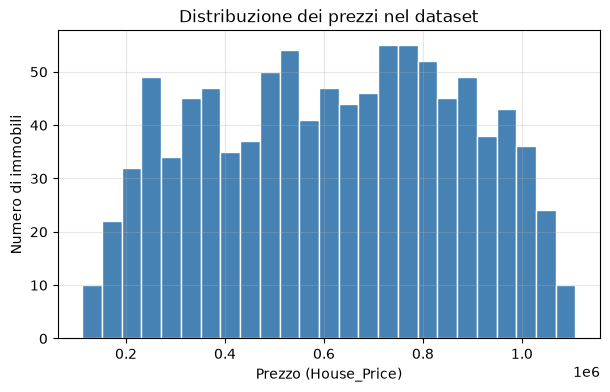

In [18]:
# Distribuzione del prezzo: ci aiuta a capire se ci sono valori estremi
# o una particolare forma della distribuzione (simmetrica, con coda lunga, ecc.)
plt.hist(df["House_Price"], bins=25, color="steelblue", edgecolor="white")
plt.xlabel("Prezzo (House_Price)")
plt.ylabel("Numero di immobili")
plt.title("Distribuzione dei prezzi nel dataset")
plt.show()


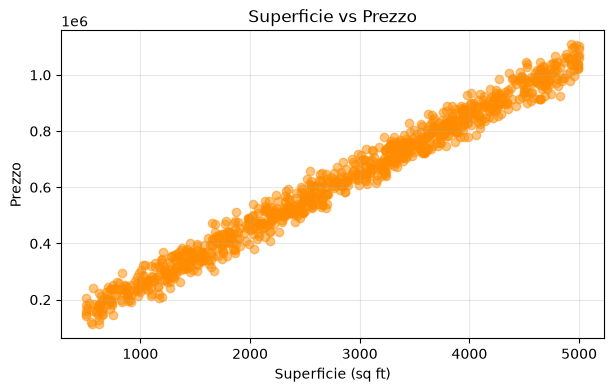

In [19]:
# Relazione tra superficie e prezzo: la feature piu' intuitivamente legata al prezzo.
# alpha=0.5 rende i punti semi-trasparenti, utile quando si sovrappongono tra loro.
plt.scatter(df["Square_Footage"], df["House_Price"], alpha=0.5, color="darkorange")
plt.xlabel("Superficie (sq ft)")
plt.ylabel("Prezzo")
plt.title("Superficie vs Prezzo")
plt.show()


In [20]:
# Correlazione di tutte le variabili numeriche con il prezzo.
# Valori vicini a +1/-1 indicano una relazione lineare forte; vicini a 0, nessuna.
# numeric_only=True esclude eventuali colonne non numeriche dal calcolo.
correlazioni = df.corr(numeric_only=True)["House_Price"].sort_values(ascending=False)
correlazioni


House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64

---
## 3. Preparazione dei dati

Come nel caso didattico, dividiamo i dati in training e test set **prima** di
allenare il modello, per poter stimare onestamente l'errore di generalizzazione
su immobili mai visti durante l'allenamento.


In [21]:
# Separiamo le feature (X) dal target (y)
X = df.drop(columns=["House_Price"])   # tutte le colonne tranne il prezzo
y = df["House_Price"]                  # solo il prezzo, cio' che vogliamo prevedere

# Dividiamo in training (80%) e test (20%). random_state fissa la casualita'
# dello shuffle, cosi' lo split e' identico ogni volta che eseguiamo la cella.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Immobili nel training set:", len(X_train))
print("Immobili nel test set:    ", len(X_test))


Immobili nel training set: 800
Immobili nel test set:     200


---
## 4. Allenamento del modello: Regressione Lineare

$$
\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_p x_p + b
$$


In [22]:
# Creiamo il modello di regressione lineare con i parametri di default
modello = LinearRegression()

# fit() e' il passo di apprendimento vero e proprio: calcola i pesi (coef_)
# e l'intercetta (intercept_) che minimizzano l'errore quadratico sul training set
modello.fit(X_train, y_train)

# predict() applica la formula appresa (y = w*x + b) a dati mai visti (X_test)
y_pred = modello.predict(X_test)


---
## 5. Calcolo della loss (MSE)

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$


In [23]:
# Calcoliamo la loss "a mano", passo dopo passo, per capire cosa fa la formula

# errori: differenza tra prezzo reale e prezzo previsto, per ogni immobile del test set
errori = y_test - y_pred

# eleviamo al quadrato ogni errore (element-wise) e ne facciamo la media:
# e' esattamente la definizione di MSE (Mean Squared Error)
mse_manuale = (errori ** 2).mean()
print(f"MSE calcolato manualmente: {mse_manuale:,.0f}")

# stessa quantita', calcolata con la funzione di libreria, come verifica
mse_sklearn = mean_squared_error(y_test, y_pred)
print(f"MSE calcolato con sklearn: {mse_sklearn:,.0f}")


MSE calcolato manualmente: 101,434,799
MSE calcolato con sklearn: 101,434,799


---
## 6. Metriche di valutazione

- **RMSE**: radice del MSE, nella stessa unità del prezzo.
- **MAE**: errore medio assoluto, meno sensibile agli outlier.
- **R²**: percentuale di variabilità del prezzo spiegata dal modello.


In [24]:
# RMSE: radice quadrata del MSE, riportata nella stessa unita' di misura del prezzo
rmse = np.sqrt(mse_sklearn)

# MAE: media del valore assoluto degli errori, meno sensibile agli outlier del MSE/RMSE
mae = mean_absolute_error(y_test, y_pred)

# R2: percentuale di variabilita' del prezzo spiegata dal modello
# (1 = perfetto, 0 = equivalente a prevedere sempre la media di y_train)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.0f}")
print(f"MAE:  {mae:,.0f}")
print(f"R2:   {r2:.3f}")


RMSE: 10,071
MAE:  8,175
R2:   0.998


---
## 7. Interpretazione dei pesi/coefficenti


In [25]:
# Estraiamo i pesi (coefficienti) appresi dal modello e li associamo al nome
# della feature corrispondente, per poterli leggere facilmente
coefficienti = pd.Series(modello.coef_, index=X.columns).sort_values(ascending=False)

print("Effetto stimato di ogni feature sul prezzo:")
for nome, valore in coefficienti.items():
    # {valore:+,.2f} mostra sempre il segno (+/-) e le migliaia separate da virgola
    print(f"  {nome:22s}: {valore:+,.2f}")



Effetto stimato di ogni feature sul prezzo:
  Lot_Size              : +14,885.38
  Num_Bedrooms          : +10,225.20
  Num_Bathrooms         : +8,208.43
  Garage_Size           : +5,146.15
  Year_Built            : +993.54
  Square_Footage        : +199.51
  Neighborhood_Quality  : +115.07
